# Аудит Wine Quality (White Wine)
 Запуск: **Runtime → Run all**.

In [3]:
# 1. Импорты
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
print('OK: библиотеки загружены')

OK: библиотеки загружены


In [4]:
# 2. Загрузка CSV без files.upload()
CSV_NAME = 'winequality-white.csv'
UCI_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/winequality-white.csv'

if not os.path.exists(CSV_NAME):
    print('Файл не найден, пробую скачать из UCI...')
    !wget -q -O {CSV_NAME} {UCI_URL}

if not os.path.exists(CSV_NAME):
    raise FileNotFoundError(
        'CSV не найден. Загрузи файл через панель Files слева (иконка папки) → Upload.'
    )

df = pd.read_csv(CSV_NAME, sep=';')
print('OK: датасет загружен, размер =', df.shape)
df.head()

OK: датасет загружен, размер = (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
# 3. Общая статистика
print('=' * 60)
print('ОБЩАЯ СТАТИСТИКА')
print('=' * 60)
print('Размер:', df.shape)
print('Признаков:', df.shape[1] - 1)
print('\nТипы данных:')
print(df.dtypes)
print('\nОписательная статистика:')
print(df.describe().T.round(3))

ОБЩАЯ СТАТИСТИКА
Размер: (4898, 12)
Признаков: 11

Типы данных:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Описательная статистика:
                       count     mean     std    min      25%      50%  \
fixed acidity         4898.0    6.855   0.844  3.800    6.300    6.800   
volatile acidity      4898.0    0.278   0.101  0.080    0.210    0.260   
citric acid           4898.0    0.334   0.121  0.000    0.270    0.320   
residual sugar        4898.0    6.391   5.072  0.600    1.700    5.200   
chlorides             4898.0    0.046   0.022  0.009    0.036    0.043   
free sulfur dioxide   4898.0   35.308  17.007  2.000   23.000   34.0

In [6]:
# 4. Пропуски
print('=' * 60)
print('ПРОПУСКИ')
print('=' * 60)
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
    print('OK: пропуски заполнены медианой')
else:
    print('OK: пропусков не обнаружено')

ПРОПУСКИ
OK: пропусков не обнаружено


In [7]:
# 5. Дубликаты
print('=' * 60)
print('ДУБЛИКАТЫ')
print('=' * 60)
n_dups = df.duplicated().sum()
print('Найдено дубликатов:', n_dups, f'({n_dups/len(df)*100:.2f}%)')
df = df.drop_duplicates().reset_index(drop=True)
print('OK: после удаления', df.shape)

ДУБЛИКАТЫ
Найдено дубликатов: 937 (19.13%)
OK: после удаления (3961, 12)


In [8]:
# 6. Константные признаки
print('=' * 60)
print('КОНСТАНТНЫЕ ПРИЗНАКИ')
print('=' * 60)
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print('Константные признаки:', const_cols if const_cols else 'нет')

КОНСТАНТНЫЕ ПРИЗНАКИ
Константные признаки: нет


Распределение классов:
quality
3      20
4     153
5    1175
6    1788
7     689
8     131
9       5
Name: count, dtype: int64

Дисбаланс max/min = 357.6


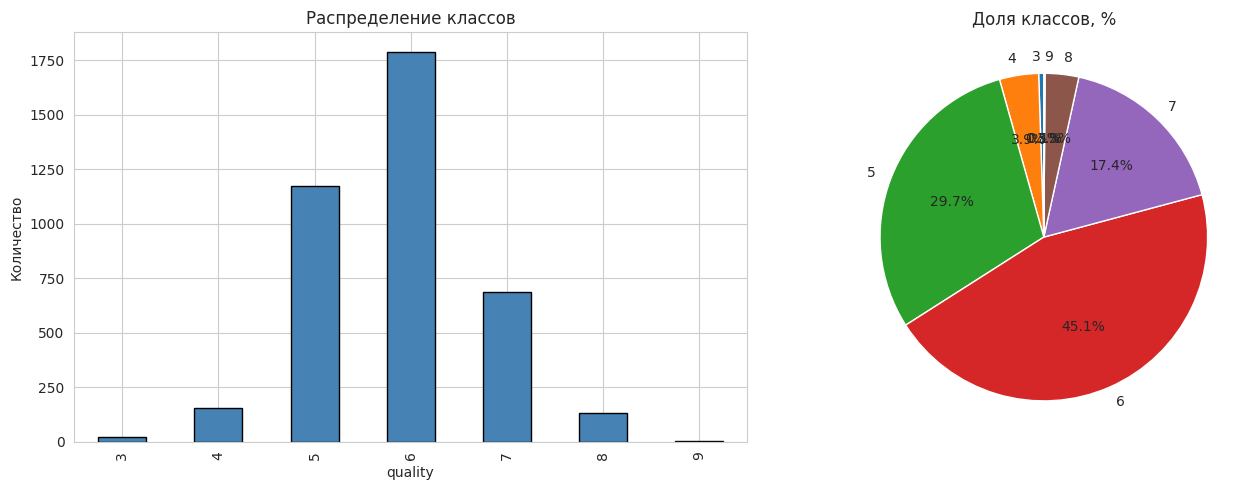

In [9]:
# 7. Баланс классов
counts = df['quality'].value_counts().sort_index()
print('Распределение классов:')
print(counts)
print('\nДисбаланс max/min =', round(counts.max() / counts.min(), 2))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
counts.plot(kind='bar', ax=ax[0], color='steelblue', edgecolor='black')
ax[0].set_title('Распределение классов')
ax[0].set_xlabel('quality')
ax[0].set_ylabel('Количество')
ax[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Доля классов, %')
plt.tight_layout()
plt.show()

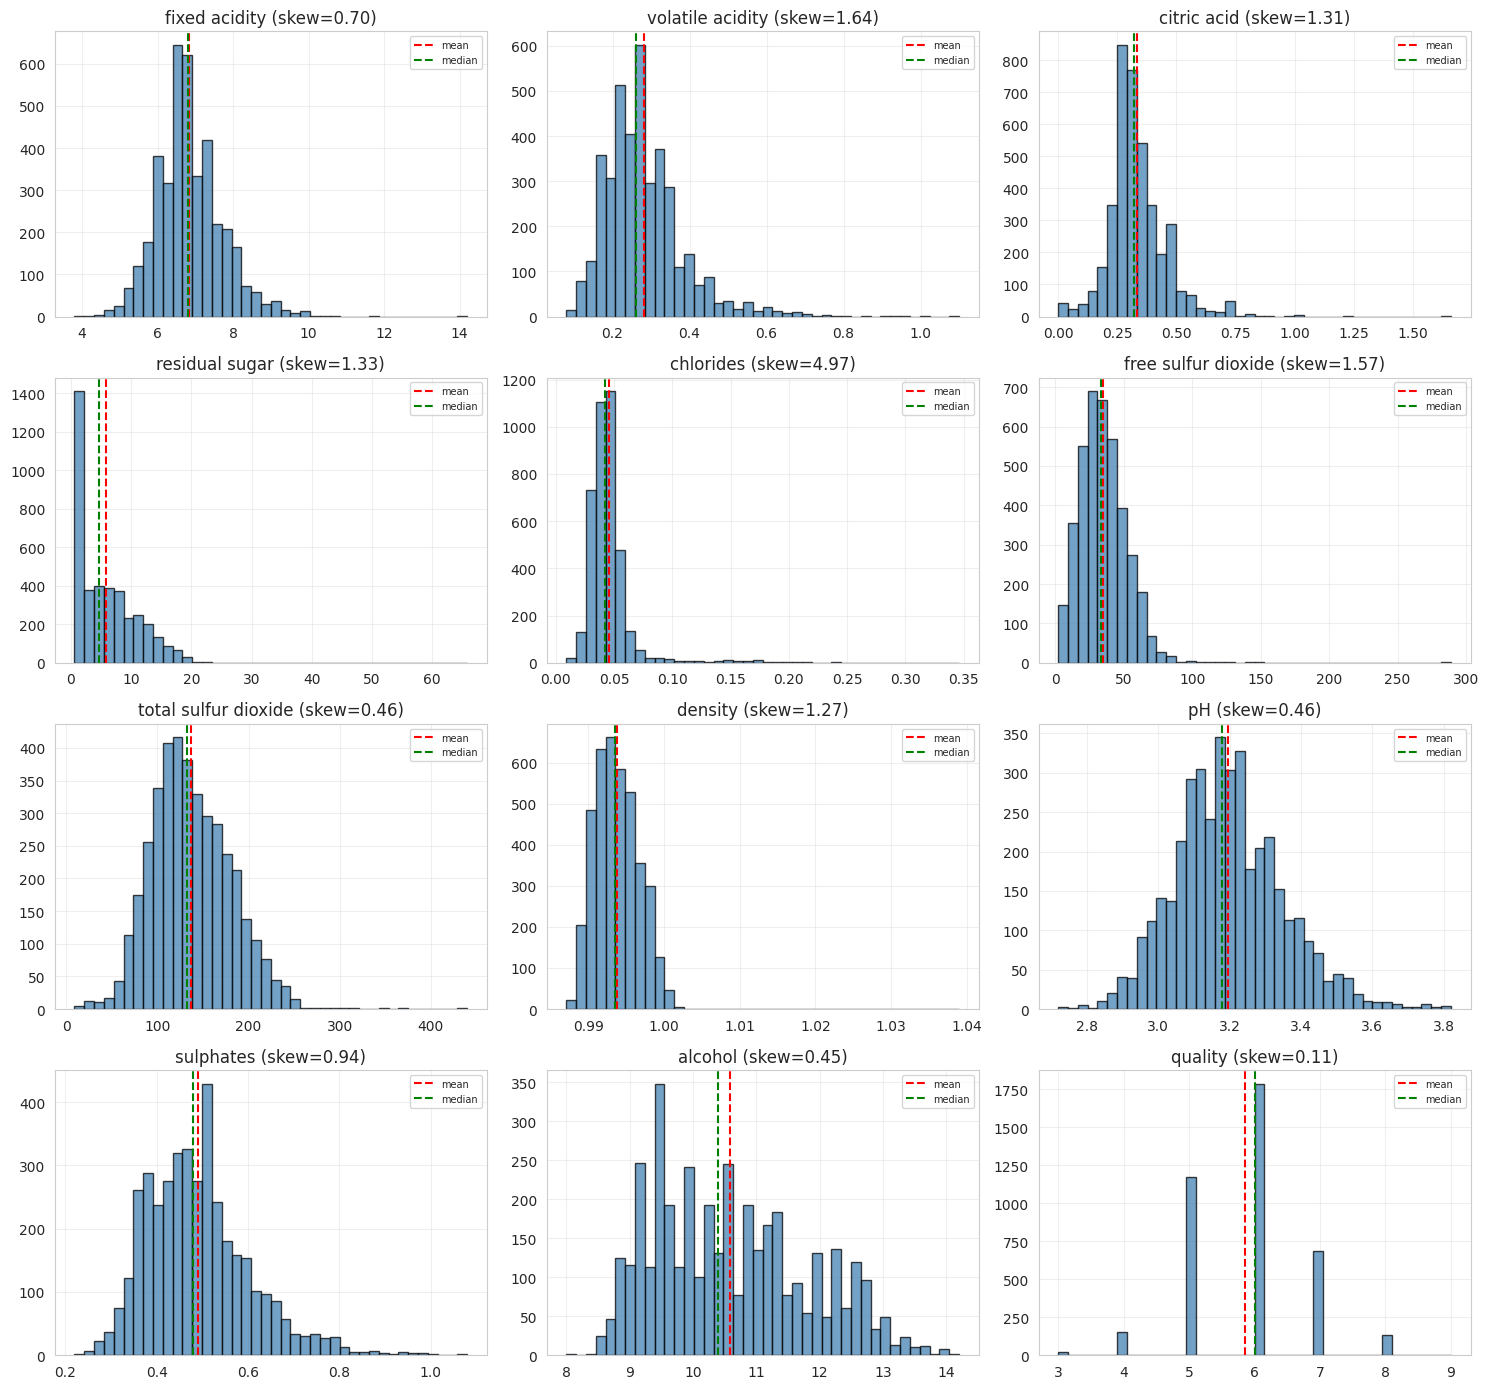

In [10]:
# 8. Распределения всех признаков
numeric_cols = df.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='black', alpha=0.75)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label='median')
    axes[i].set_title(f'{col} (skew={df[col].skew():.2f})')
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('distributions.png', dpi=100, bbox_inches='tight')
plt.show()

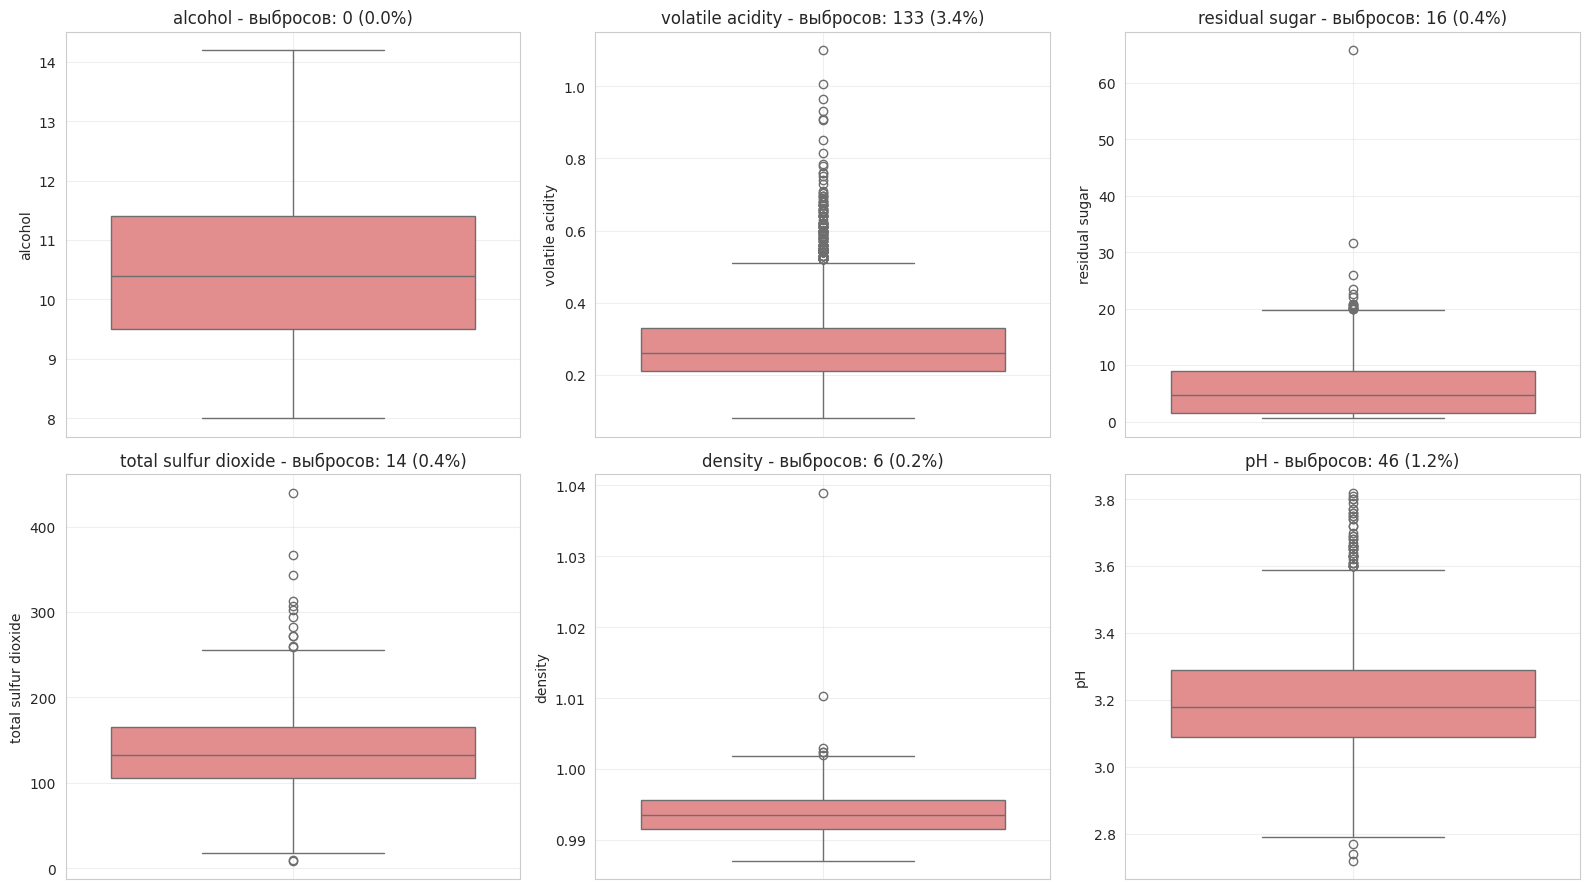

Выбросы по IQR:
  alcohol: 0 (0.0%)
  volatile acidity: 133 (3.4%)
  residual sugar: 16 (0.4%)
  total sulfur dioxide: 14 (0.4%)
  density: 6 (0.2%)
  pH: 46 (1.2%)


In [11]:
# 9. Boxplot для приоритетных признаков
priority = ['alcohol', 'volatile acidity', 'residual sugar',
            'total sulfur dioxide', 'density', 'pH']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
report = {}

for i, col in enumerate(priority):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = int(((df[col] < lower) | (df[col] > upper)).sum())
    report[col] = n_out
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'{col} - выбросов: {n_out} ({n_out/len(df)*100:.1f}%)')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('boxplots_priority.png', dpi=100, bbox_inches='tight')
plt.show()

print('Выбросы по IQR:')
for k, v in report.items():
    print(f'  {k}: {v} ({v/len(df)*100:.1f}%)')

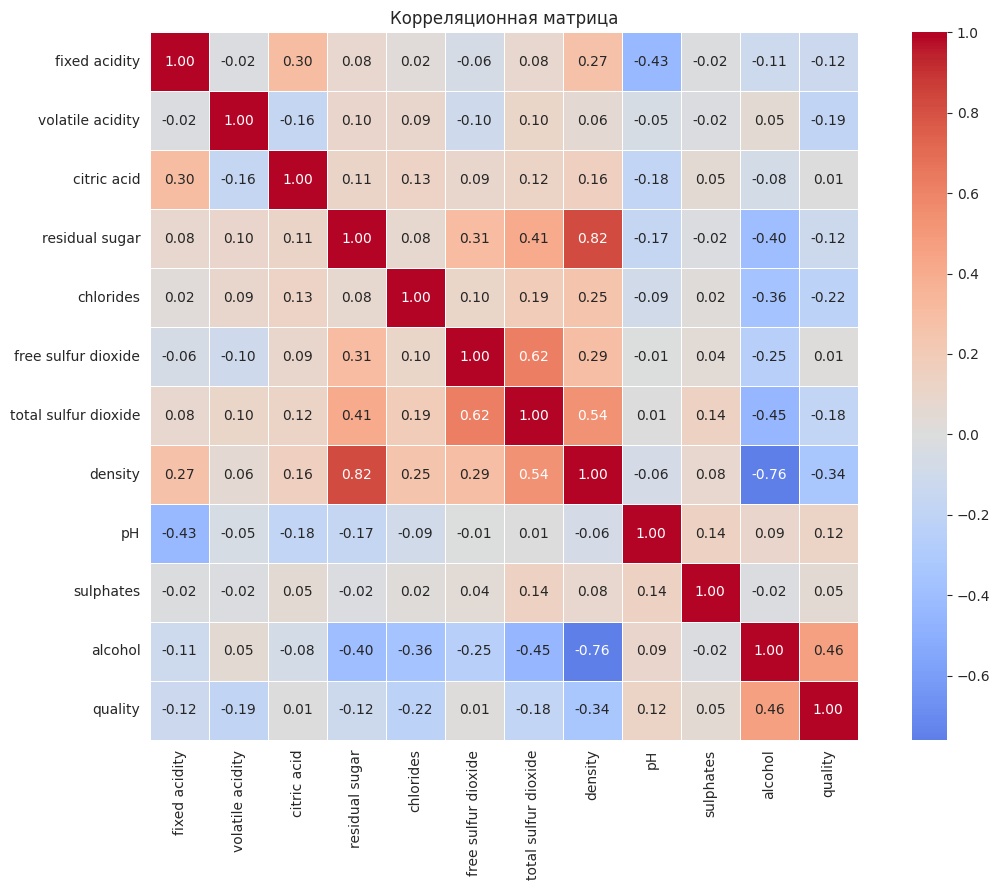

Корреляция с quality (по модулю):
alcohol                 0.463
density                -0.338
chlorides              -0.218
volatile acidity       -0.191
total sulfur dioxide   -0.183
fixed acidity          -0.125
pH                      0.124
residual sugar         -0.117
sulphates               0.053
free sulfur dioxide     0.011
citric acid             0.007
Name: quality, dtype: float64


In [12]:
# 10. Корреляции
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.savefig('correlation.png', dpi=100, bbox_inches='tight')
plt.show()

print('Корреляция с quality (по модулю):')
print(corr['quality'].drop('quality').sort_values(key=abs, ascending=False).round(3))

In [13]:
# 11. Сохранение очищенного датасета
df.to_csv('winequality_white_clean.csv', index=False)
print('OK: сохранён winequality_white_clean.csv, размер =', df.shape)
print('Файлы результатов доступны в панели Files слева.')

OK: сохранён winequality_white_clean.csv, размер = (3961, 12)
Файлы результатов доступны в панели Files слева.


## Выводы

1. Пропуски отсутствуют.
2. Дубликаты (~19%) удалены.
3. Константных признаков нет.
4. Сильный дисбаланс классов: оценки 5 и 6 доминируют.
5. Асимметрия: residual sugar, chlorides, sulphates.
6. Выбросы больше всего в residual sugar и chlorides.
7. Топ-признаки: alcohol (+), volatile acidity (-), density (-).